In [1]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import os

## Initial conditions — test142 to test150

Replicates the **test41** setup (slope width = 5 grid cells, depth 100→500 m, tanh velocity)
across 9 different grid resolutions.

**Fixed across all experiments:**
- Domain: $L_x = 1000$ km, $L_y = 400$ km
- Velocity: $u = U\tanh\!\left(\frac{y - Y_j}{L_\mathrm{jet}}\right)$, $U=0.20$ m/s, $L_\mathrm{jet}=10$ km
- Topography: shelf 100 m, slope width = 5 grid cells centred at $Y_s = 200$ km, basin 500 m
- $f = -10^{-5}$ s$^{-1}$

**Varies between experiments — grid resolution (dx = dy):**

| Experiment | dx = dy | nx    | ny   |
|------------|---------|-------|------|
| test142    | 900 m   | 1111  | 444  |
| test143    | 800 m   | 1250  | 500  |
| test144    | 700 m   | 1428  | 571  |
| test145    | 600 m   | 1666  | 666  |
| test146    | 500 m   | 2000  | 800  |
| test147    | 400 m   | 2500  | 1000 |
| test148    | 300 m   | 3333  | 1333 |
| test149    | 200 m   | 5000  | 2000 |
| test150    | 100 m   | 10000 | 4000 |

> **Note:** 700 m and 600 m do not divide evenly into the domain lengths.
> `nx` and `ny` are truncated with `int()`, so the effective domain is
> very slightly smaller than 1000 × 400 km for those two cases.

### Shared physical constants

In [2]:
# Domain size (fixed)
Lx = 1000e3   # m
Ly = 400e3    # m

# Velocity parameters
f    = -1e-5   # s^-1
g    = 9.81    # m s^-2
U    = 0.20    # m s^-1  jet amplitude
Ljet = 10e3   # m       jet half-width
Yj   = Ly / 2  # m       jet centre

# Bathymetry parameters (test41 topology)
shallow_depth = 100.0   # m  shelf
deep_depth    = 500.0   # m  basin
# Slope: width = 5 grid cells, centred at Ys = 200 km
# slope_start and slope_end are computed per resolution inside the loop
slope_width   = 5       # grid cells  (same as test41)
Ys            = 200e3   # m  slope centre (200 km)

### Experiment loop

In [3]:
base_dir = '/scratch/nm03/ae7501/mom6_input_directories/idealized'

# (experiment_number, resolution_in_metres)
experiments = [(142 + i, res) for i, res in enumerate(range(900, 0, -100))]

for exp_num, res in experiments:

    exp_name  = f'test{exp_num}'
    input_dir = os.path.join(base_dir, exp_name, 'INPUT')
    os.makedirs(input_dir, exist_ok=True)

    # ── Grid for this resolution ──────────────────────────────────────────────
    dx  = res
    dy  = res
    nx  = int(Lx / dx)
    ny  = int(Ly / dy)
    nxp = nx + 1
    nyp = ny + 1

    xh = np.linspace(dx/2, nx*dx - dx/2, nx)
    yh = np.linspace(dy/2, ny*dy - dy/2, ny)
    xq = np.linspace(0, nx*dx, nxp)
    yq = np.linspace(0, ny*dy, nyp)

    Xh, Yh   = np.meshgrid(xh, yh)
    Xq, Yh_u = np.meshgrid(xq, yh)
    Xh_v, Yq = np.meshgrid(xh, yq)

    # ── Slope indices for this resolution ─────────────────────────────────────
    # Slope is always 5 cells wide, centred at Ys = 200 km.
    # Even width -> centre on cell index = Ys/dy, start = centre - width//2
    slope_centre_idx = int(Ys / dy)
    slope_start      = slope_centre_idx - slope_width // 2
    slope_end        = slope_start + slope_width

    print(f"\n{'='*60}")
    print(f' {exp_name}  |  dx=dy={res}m  nx={nx}  ny={ny}')
    print(f' slope indices: [{slope_start}, {slope_end})  '
          f'y = [{yh[slope_start]/1e3:.2f}, {yh[slope_end-1]/1e3:.2f}] km')

    # ── Velocity field ────────────────────────────────────────────────────────
    yprime_u = (Yh_u - Yj) / Ljet
    u_clean  = U * np.tanh(yprime_u)
    v        = np.zeros((nyp, nx))

    # Fixed-seed noise (reproducible, same character across resolutions)
    rng          = np.random.default_rng(seed=42)
    random_noise = rng.standard_normal(u_clean.shape)
    decay_factor = 1.0 / np.cosh(yprime_u)**2
    u            = u_clean + 1e-3 * decay_factor * random_noise

    # ── Free surface (geostrophically balanced) ───────────────────────────────
    yprime_h = (Yh - Yj) / Ljet
    eta_t    = -(f * U * Ljet / g) * np.log(np.cosh(yprime_h))
    eta_t   -= eta_t.mean()

    # ── Bathymetry ────────────────────────────────────────────────────────────
    depth_profile_y = np.zeros(ny)
    depth_profile_y[:slope_start]          = shallow_depth
    depth_profile_y[slope_start:slope_end] = np.linspace(shallow_depth, deep_depth, slope_width)
    depth_profile_y[slope_end:]            = deep_depth
    depth_2d = np.tile(depth_profile_y[:, np.newaxis], (1, nx))

    # 3-D arrays for NetCDF
    zl   = 1
    z    = np.array([-250.0])
    h_3d = eta_t[np.newaxis, :, :]
    u_3d = u    [np.newaxis, :, :]
    v_3d = v    [np.newaxis, :, :]

    # ── Write init_vel.nc ─────────────────────────────────────────────────────
    vel_path = os.path.join(input_dir, 'init_vel.nc')
    nc_vel   = Dataset(vel_path, 'w', format='NETCDF4')
    nc_vel.createDimension('zl', zl)
    nc_vel.createDimension('yh', ny)
    nc_vel.createDimension('xh', nx)
    nc_vel.createDimension('yq', nyp)
    nc_vel.createDimension('xq', nxp)

    zl_v = nc_vel.createVariable('zl', 'f4', ('zl',))
    zl_v[:] = z ; zl_v.axis = 'Z' ; zl_v.long_name = 'depth to layer'

    xh_v = nc_vel.createVariable('xh', 'f4', ('xh',))
    xh_v[:] = xh ; xh_v.axis = 'X'
    xh_v.long_name = 'h-point longitude' ; xh_v.units = 'meters'

    yh_v = nc_vel.createVariable('yh', 'f4', ('yh',))
    yh_v[:] = yh ; yh_v.axis = 'Y'
    yh_v.long_name = 'h-point latitude' ; yh_v.units = 'meters'

    xq_v = nc_vel.createVariable('xq', 'f4', ('xq',))
    xq_v[:] = xq ; xq_v.axis = 'X'
    xq_v.long_name = 'q-point longitude' ; xq_v.units = 'meters'

    yq_v = nc_vel.createVariable('yq', 'f4', ('yq',))
    yq_v[:] = yq ; yq_v.axis = 'Y'
    yq_v.long_name = 'q-point latitude' ; yq_v.units = 'meters'

    u_var = nc_vel.createVariable('u', 'f4', ('zl', 'yh', 'xq'))
    u_var[:] = u_3d
    u_var.units = 'm s-1'
    u_var.long_name = 'Eastward velocity'
    u_var.standard_name = 'eastward_sea_water_velocity'

    v_var = nc_vel.createVariable('v', 'f4', ('zl', 'yq', 'xh'))
    v_var[:] = v_3d
    v_var.units = 'm s-1'
    v_var.long_name = 'Northward velocity'
    v_var.standard_name = 'northward_sea_water_velocity'

    nc_vel.regrid_method = 'bilinear'
    nc_vel.close()
    print(f' Written: {vel_path}')

    # ── Write init_eta.nc ─────────────────────────────────────────────────────
    eta_path = os.path.join(input_dir, 'init_eta.nc')
    nc_h     = Dataset(eta_path, 'w', format='NETCDF4')
    nc_h.createDimension('yh', ny)
    nc_h.createDimension('xh', nx)

    xh_v2 = nc_h.createVariable('xh', 'f4', ('xh',))
    xh_v2[:] = xh ; xh_v2.axis = 'X'
    xh_v2.long_name = 'h-point longitude' ; xh_v2.units = 'meters'

    yh_v2 = nc_h.createVariable('yh', 'f4', ('yh',))
    yh_v2[:] = yh ; yh_v2.axis = 'Y'
    yh_v2.long_name = 'h-point latitude' ; yh_v2.units = 'meters'

    h_var = nc_h.createVariable('eta_t', 'f4', ('yh', 'xh'))
    h_var[:] = h_3d
    h_var.units = 'm'
    h_var.long_name = 'Free surface height anomaly'
    h_var.standard_name = 'sea_floor_depth_below_sea_surface'

    nc_h.close()
    print(f' Written: {eta_path}')

    # ── Write ocean_topog.nc ──────────────────────────────────────────────────
    topo_path = os.path.join(input_dir, 'ocean_topog.nc')
    nc_d      = Dataset(topo_path, 'w', format='NETCDF4')
    nc_d.createDimension('yh', ny)
    nc_d.createDimension('xh', nx)

    xh_d = nc_d.createVariable('xh', 'f4', ('xh',))
    xh_d[:] = xh
    xh_d.long_name = 't-cell center x-location' ; xh_d.units = 'meters'

    yh_d = nc_d.createVariable('yh', 'f4', ('yh',))
    yh_d[:] = yh
    yh_d.long_name = 't-cell center y-location' ; yh_d.units = 'meters'

    depth_var = nc_d.createVariable('depth', 'f4', ('yh', 'xh'))
    depth_var[:] = depth_2d
    depth_var.units = 'm'
    depth_var.long_name = 'ocean bottom depth'
    depth_var.standard_name = 'sea_floor_depth_below_geoid'

    nc_d.close()
    print(f' Written: {topo_path}')

print(f"\n{'='*60}")
print('All 9 experiments written successfully (test142-test150).')
print(f"{'='*60}")


 test142  |  dx=dy=900m  nx=1111  ny=444
 slope indices: [220, 225)  y = [198.45, 202.05] km
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test142/INPUT/init_vel.nc
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test142/INPUT/init_eta.nc
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test142/INPUT/ocean_topog.nc

 test143  |  dx=dy=800m  nx=1250  ny=500
 slope indices: [248, 253)  y = [198.80, 202.00] km
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test143/INPUT/init_vel.nc
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test143/INPUT/init_eta.nc
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test143/INPUT/ocean_topog.nc

 test144  |  dx=dy=700m  nx=1428  ny=571
 slope indices: [283, 288)  y = [198.45, 201.25] km
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test144/INPUT/init_vel.nc
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test144/INPUT/init

### Sanity-check plot — bathymetry profiles for all resolutions

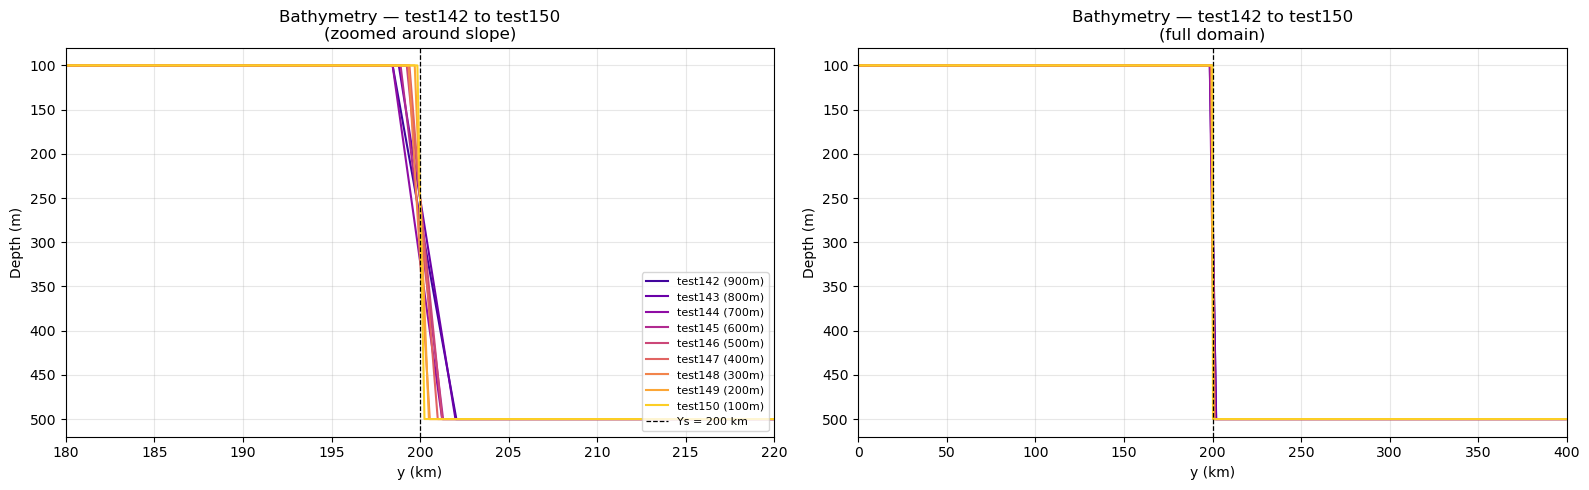

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(experiments)))

for ax, xlim, title_suffix in zip(
        axes,
        [(180, 220), (0, 400)],
        ['(zoomed around slope)', '(full domain)']):

    for i, (exp_num, res) in enumerate(experiments):
        dx = dy = res
        ny_loc = int(Ly / dy)
        yh_loc = np.linspace(dy/2, ny_loc*dy - dy/2, ny_loc)

        slope_centre_idx = int(Ys / dy)
        ss = slope_centre_idx - slope_width // 2
        se = ss + slope_width

        profile = np.zeros(ny_loc)
        profile[:ss]   = shallow_depth
        profile[ss:se] = np.linspace(shallow_depth, deep_depth, slope_width)
        profile[se:]   = deep_depth

        ax.plot(yh_loc/1e3, profile, color=colors[i],
                label=f'test{exp_num} ({res}m)')

    ax.axvline(Ys/1e3, color='k', linestyle='--', linewidth=0.9,
               label=f'Ys = {Ys/1e3:.0f} km')
    ax.set_xlim(xlim)
    ax.set_xlabel('y (km)')
    ax.set_ylabel('Depth (m)')
    ax.invert_yaxis()
    ax.set_title(f'Bathymetry — test142 to test150\n{title_suffix}')
    ax.grid(True, alpha=0.3)

axes[0].legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()